In [ ]:
import pandas as pd

df = pd.read_csv("recruitment_dataset-1.csv") #Load the dataset from a CSV file


df.head() #Show the first few rows of the dataset 

,Candidate_ID,Source,Submission_Date,Interview_Date,Interview_Status,Offer_Status,Client,Position,Location,Experience,Aptitude_Score,Technical_Score,HR_Score,Salary_Offered,Department
0,1,LinkedIn,2025-01-01,2025-01-05,Selected,Offered,Tech Mahindra,Data Engineer,CA,0,68,48,56,17,Sales
1,2,Dice,2025-01-02,2025-01-06,Rejected,Not Offered,HCL,DevOps Engineer,TX,8,69,92,92,14,Data Science
2,3,Monster,2025-01-03,NaN,Rejected,Not Offered,Infosys,Java Developer,NY,1,81,45,61,11,Sales
3,4,LinkedIn,2025-01-04,2025-01-08,Selected,Offered,Wipro,Data Analyst,IL,0,45,53,92,13,Sales
4,5,Dice,2025-01-05,NaN,Rejected,Not Offered,TCS,Python Developer,AZ,3,91,64,68,5,Data Science


In [22]:
df.info() #Get information about the dataset, including data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Candidate_ID      10 non-null     int64 
 1   Source            10 non-null     object
 2   Submission_Date   10 non-null     object
 3   Interview_Date    6 non-null      object
 4   Interview_Status  10 non-null     object
 5   Offer_Status      10 non-null     object
 6   Client            10 non-null     object
 7   Position          10 non-null     object
 8   Location          10 non-null     object
 9   Experience        10 non-null     int64 
 10  Aptitude_Score    10 non-null     int64 
 11  Technical_Score   10 non-null     int64 
 12  HR_Score          10 non-null     int64 
 13  Salary_Offered    10 non-null     int64 
 14  Department        10 non-null     object
dtypes: int64(6), object(9)
memory usage: 1.3+ KB


In [23]:
df.describe() #Get summary statistics for numerical columns in the dataset

,Candidate_ID,Experience,Aptitude_Score,Technical_Score,HR_Score,Salary_Offered
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,2.700000,69.300000,66.800000,75.000000,11.700000
std,3.02765,3.465705,17.416786,20.932696,13.872435,3.917199
min,1.00000,0.000000,40.000000,43.000000,56.000000,5.000000
25%,3.25000,0.000000,61.250000,49.250000,62.750000,10.250000
50%,5.50000,1.000000,69.500000,59.500000,75.000000,12.000000
75%,7.75000,4.500000,80.500000,87.250000,87.500000,14.750000
max,10.00000,9.000000,91.000000,95.000000,92.000000,17.000000


In [24]:
df.isnull().sum() #Check for missing values in each column

Candidate_ID        0
Source              0
Submission_Date     0
Interview_Date      4
Interview_Status    0
Offer_Status        0
Client              0
Position            0
Location            0
Experience          0
Aptitude_Score      0
Technical_Score     0
HR_Score            0
Salary_Offered      0
Department          0
dtype: int64

In [25]:
# Convert date columns to datetime format
df['Submission_Date'] = pd.to_datetime(df['Submission_Date'])
df['Interview_Date'] = pd.to_datetime(df['Interview_Date'])

# Check again
df.head()

,Candidate_ID,Source,Submission_Date,Interview_Date,Interview_Status,Offer_Status,Client,Position,Location,Experience,Aptitude_Score,Technical_Score,HR_Score,Salary_Offered,Department
0,1,LinkedIn,2025-01-01,2025-01-05,Selected,Offered,Tech Mahindra,Data Engineer,CA,0,68,48,56,17,Sales
1,2,Dice,2025-01-02,2025-01-06,Rejected,Not Offered,HCL,DevOps Engineer,TX,8,69,92,92,14,Data Science
2,3,Monster,2025-01-03,NaT,Rejected,Not Offered,Infosys,Java Developer,NY,1,81,45,61,11,Sales
3,4,LinkedIn,2025-01-04,2025-01-08,Selected,Offered,Wipro,Data Analyst,IL,0,45,53,92,13,Sales
4,5,Dice,2025-01-05,NaT,Rejected,Not Offered,TCS,Python Developer,AZ,3,91,64,68,5,Data Science


In [27]:
import numpy as np

# Create salary in LPA
df['Salary_LPA'] = np.round(3 + np.random.rand(len(df)) * 17, 2)

# Convert to INR
df['Salary_INR'] = df['Salary_LPA'] * 100000

df[['Salary_LPA', 'Salary_INR']].head() #Show the new salary columns in both LPA and INR

,Salary_LPA,Salary_INR
0,7.32,732000.0
1,6.91,691000.0
2,18.06,1806000.0
3,8.78,878000.0
4,13.80,1380000.0


In [28]:
df.head() #Show the updated dataset with new salary columns

,Candidate_ID,Source,Submission_Date,Interview_Date,Interview_Status,Offer_Status,Client,Position,Location,Experience,Aptitude_Score,Technical_Score,HR_Score,Salary_Offered,Department,Salary_LPA,Salary_INR
0,1,LinkedIn,2025-01-01,2025-01-05,Selected,Offered,Tech Mahindra,Data Engineer,CA,0,68,48,56,17,Sales,7.32,732000.0
1,2,Dice,2025-01-02,2025-01-06,Rejected,Not Offered,HCL,DevOps Engineer,TX,8,69,92,92,14,Data Science,6.91,691000.0
2,3,Monster,2025-01-03,NaT,Rejected,Not Offered,Infosys,Java Developer,NY,1,81,45,61,11,Sales,18.06,1806000.0
3,4,LinkedIn,2025-01-04,2025-01-08,Selected,Offered,Wipro,Data Analyst,IL,0,45,53,92,13,Sales,8.78,878000.0
4,5,Dice,2025-01-05,NaT,Rejected,Not Offered,TCS,Python Developer,AZ,3,91,64,68,5,Data Science,13.80,1380000.0


In [29]:
df.drop('Salary_Offered', axis=1, inplace=True)

In [30]:
df.head() #Show the updated dataset with new salary columns

,Candidate_ID,Source,Submission_Date,Interview_Date,Interview_Status,Offer_Status,Client,Position,Location,Experience,Aptitude_Score,Technical_Score,HR_Score,Department,Salary_LPA,Salary_INR
0,1,LinkedIn,2025-01-01,2025-01-05,Selected,Offered,Tech Mahindra,Data Engineer,CA,0,68,48,56,Sales,7.32,732000.0
1,2,Dice,2025-01-02,2025-01-06,Rejected,Not Offered,HCL,DevOps Engineer,TX,8,69,92,92,Data Science,6.91,691000.0
2,3,Monster,2025-01-03,NaT,Rejected,Not Offered,Infosys,Java Developer,NY,1,81,45,61,Sales,18.06,1806000.0
3,4,LinkedIn,2025-01-04,2025-01-08,Selected,Offered,Wipro,Data Analyst,IL,0,45,53,92,Sales,8.78,878000.0
4,5,Dice,2025-01-05,NaT,Rejected,Not Offered,TCS,Python Developer,AZ,3,91,64,68,Data Science,13.80,1380000.0


In [31]:
df.to_csv("final_recruitment_dataset.csv", index=False) #Save the cleaned and updated dataset to a new CSV file

In [32]:
df.isnull().sum()

Candidate_ID        0
Source              0
Submission_Date     0
Interview_Date      4
Interview_Status    0
Offer_Status        0
Client              0
Position            0
Location            0
Experience          0
Aptitude_Score      0
Technical_Score     0
HR_Score            0
Department          0
Salary_LPA          0
Salary_INR          0
dtype: int64

In [33]:
df.dropna(inplace=True) #Drop any remaining rows with missing values 

In [34]:
df.isnull().sum() #Check for missing values in each column

Candidate_ID        0
Source              0
Submission_Date     0
Interview_Date      0
Interview_Status    0
Offer_Status        0
Client              0
Position            0
Location            0
Experience          0
Aptitude_Score      0
Technical_Score     0
HR_Score            0
Department          0
Salary_LPA          0
Salary_INR          0
dtype: int64

In [35]:
df.to_csv("final_cleaned_recruitment_data.csv", index=False) 
#Save the final cleaned dataset to a new CSV file for use in the dashboard

In [36]:
# Total candidates
total = len(df)

# Selection rate
selection_rate = (df['Offer_Status'] == 'Offered').mean()

# Avg salary
avg_salary = df['Salary_LPA'].mean()

# Avg experience
avg_exp = df['Experience'].mean()

print("Total:", total)
print("Selection Rate:", round(selection_rate,2))
print("Avg Salary:", round(avg_salary,2))
print("Avg Experience:", round(avg_exp,2))

Total: 6
Selection Rate: 0.67
Avg Salary: 6.69
Avg Experience: 3.0


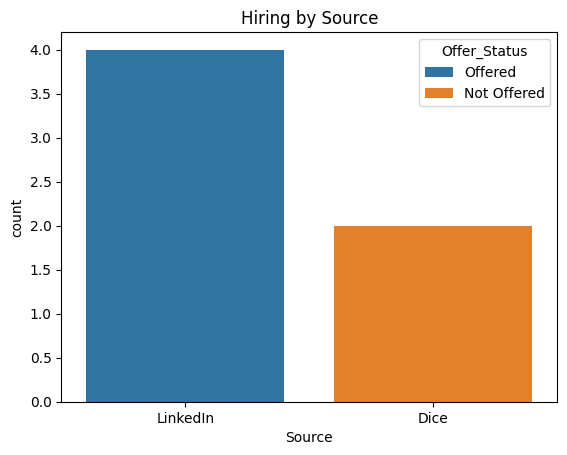

In [37]:
# Hiring by source
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Source', hue='Offer_Status', data=df)
plt.title("Hiring by Source")
plt.show()


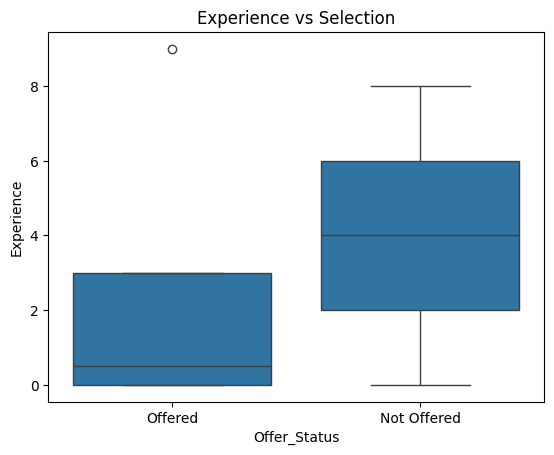

In [38]:
# Experience vs Selection
sns.boxplot(x='Offer_Status', y='Experience', data=df)
plt.title("Experience vs Selection")
plt.show()

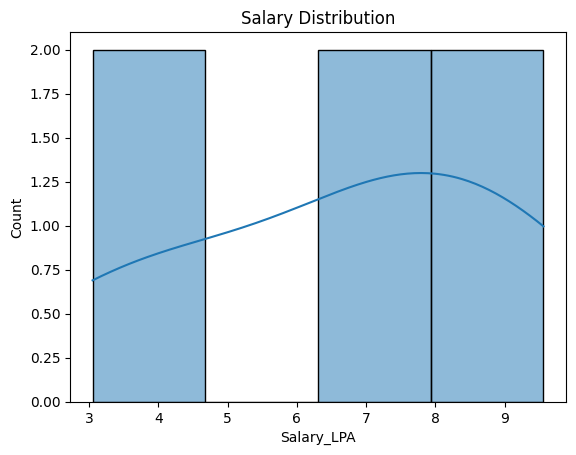

In [39]:
# Salary distribution
sns.histplot(df['Salary_LPA'], kde=True)
plt.title("Salary Distribution")
plt.show()

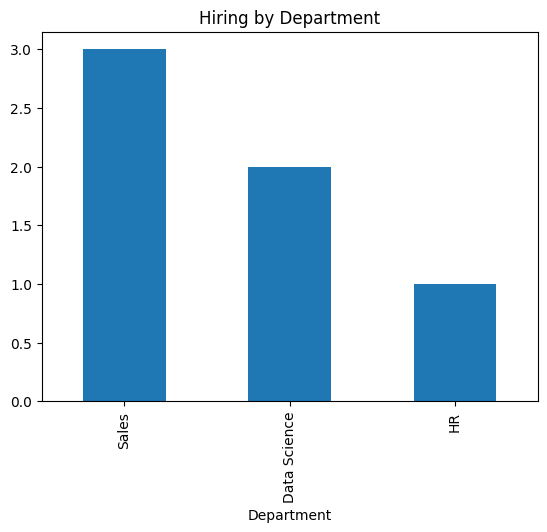

In [40]:
# Hiring by department
df['Department'].value_counts().plot(kind='bar')
plt.title("Hiring by Department")
plt.show()

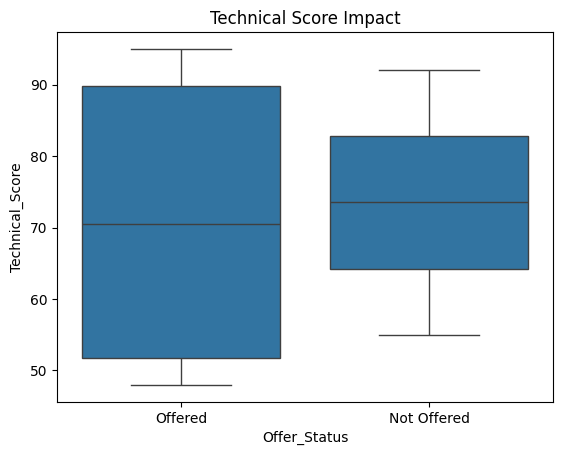

In [ ]:
# Technical score impact (Scores vs Selection) 
sns.boxplot(x='Offer_Status', y='Technical_Score', data=df)
plt.title("Technical Score Impact")
plt.show()

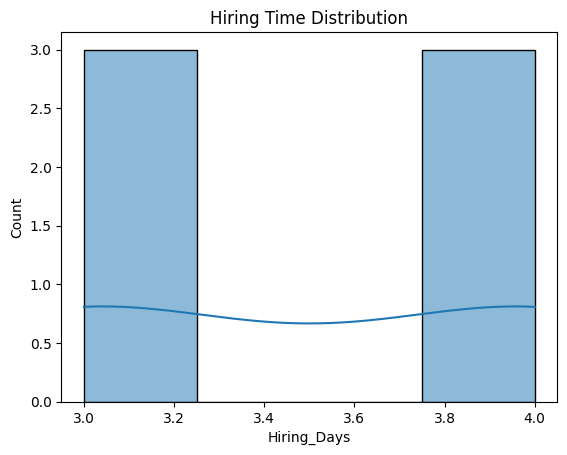

In [42]:
# Hiring time analysis (Time from submission to interview)
df['Hiring_Days'] = (df['Interview_Date'] - df['Submission_Date']).dt.days

sns.histplot(df['Hiring_Days'], kde=True)
plt.title("Hiring Time Distribution")
plt.show()

# 📌 Key Insights
- LinkedIn is the most effective hiring source with highest offer conversion
- Candidates with higher technical scores are more likely to be selected
- Average salary increases with experience
- Data Science roles have higher hiring demand
- Most hiring is completed within X days

“I performed EDA to understand hiring trends, candidate performance, and source effectiveness. I found that technical scores and experience significantly impact selection, and LinkedIn is the most effective sourcing channel.”